# Evolución de patrimonio - Inversion Buy & Hold

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import yfinance as yf

INITIAL_PER_TICKER = 10_000
MONTHLY_PER_TICKER = 0#1_000


## Definimos el listado de acciones

In [72]:
symbols_list = []
symbols_list.append('AGUAS-A.SN')
symbols_list.append('ANDINA-B.SN')
symbols_list.append('ANTARCHILE.SN')
symbols_list.append('BCI.SN')
symbols_list.append('BESALCO.SN')
symbols_list.append('BICE.SN')
symbols_list.append('BSANTANDER.SN')
symbols_list.append('CAP.SN')
symbols_list.append('CCU.SN')
symbols_list.append('CENCOMALLS.SN')
symbols_list.append('CENCOSUD.SN')
symbols_list.append('CHILE.SN')
symbols_list.append('CMPC.SN')
symbols_list.append('COLBUN.SN')
symbols_list.append('CONCHATORO.SN')
symbols_list.append('COPEC.SN')
symbols_list.append('ECL.SN')
symbols_list.append('EMBONOR-B.SN')
symbols_list.append('ENELAM.SN')
symbols_list.append('ENELCHILE.SN')
symbols_list.append('ENELGXCH.SN')
symbols_list.append('ENTEL.SN')
symbols_list.append('FALABELLA.SN')
symbols_list.append('FORUS.SN')
symbols_list.append('IAM.SN')
symbols_list.append('ILC.SN')
symbols_list.append('ITAUCL.SN')
symbols_list.append('LTM.SN')
symbols_list.append('MALLPLAZA.SN')
symbols_list.append('MASISA.SN')
symbols_list.append('ORO-BLANCO.SN')
symbols_list.append('PARAUCO.SN')
symbols_list.append('QUINENCO.SN')
symbols_list.append('RIPLEY.SN')
symbols_list.append('SALFACORP.SN')
symbols_list.append('SK.SN')
symbols_list.append('SMSAAM.SN')
symbols_list.append('SMU.SN')
symbols_list.append('SONDA.SN')
symbols_list.append('SQM-B.SN')
symbols_list.append('VAPORES.SN')


## Definimos el rango de fechas

In [73]:
start_date = "2008-01-01"
end_date = '2026-06-30'

## Descargamos datos

In [74]:
dfSource = yf.download(tickers=symbols_list,
                 start=start_date,
                 end=end_date,auto_adjust=False).stack()

dfSource.index.names = ['date', 'ticker']

dfSource.columns = dfSource.columns.str.lower()

dfSource

[*********************100%***********************]  41 of 41 completed
/tmp/ipykernel_829/2666454239.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  end=end_date,auto_adjust=False).stack()


Price                        adj close         close          high  \
date       ticker                                                    
2008-01-01 AGUAS-A.SN        59.882904    193.330002    193.330002   
           ANDINA-B.SN      704.098755   1440.000000   1440.000000   
           ANTARCHILE.SN   9516.041016  11500.000000  11500.000000   
           BICE.SN           30.063269     60.945553     60.945553   
           BSANTANDER.SN     11.132936     24.490000     24.490000   
...                                ...           ...           ...   
2026-06-26 SMSAAM.SN        149.070007    149.070007    147.690002   
           SMU.SN           132.899994    132.899994    133.380005   
           SONDA.SN         284.269989    284.269989    285.000000   
           SQM-B.SN       65950.000000  65950.000000  66390.000000   
           VAPORES.SN        43.790001     43.790001     43.790001   

Price                              low          open      volume  
date       ticker                                                 
2008-01-01 AGUAS-A.SN       193.330002    193.330002         0.0  
           ANDINA-B.SN     1440.000000   1440.000000         0.0  
           ANTARCHILE.SN  11500.000000  11500.000000         0.0  
           BICE.SN           60.945553     60.945553         0.0  
           BSANTANDER.SN     24.490000     24.490000  83293072.0  
...                                ...           ...         ...  
2026-06-26 SMSAAM.SN        147.690002    147.690002     15806.0  
           SMU.SN           131.600006    130.500000  10169976.0  
           SONDA.SN         281.100006    284.200012    605536.0  
           SQM-B.SN       65113.000000  66390.000000    400900.0  
           VAPORES.SN        42.299999     42.599998  22935406.0  

[177232 rows x 6 columns]

## Graficamos los precios de cierre

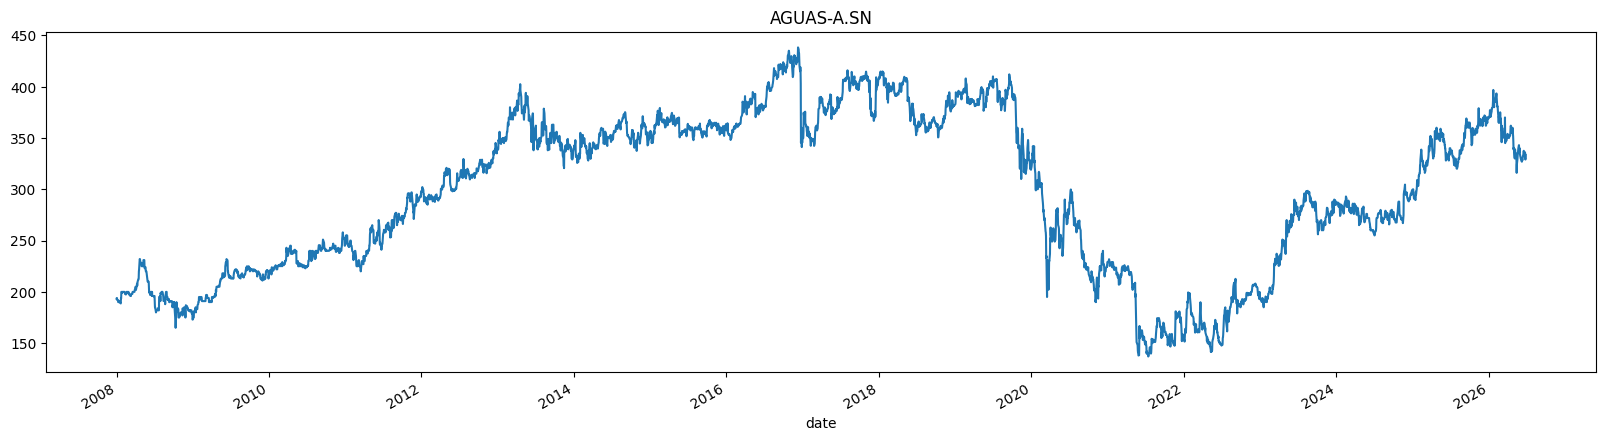

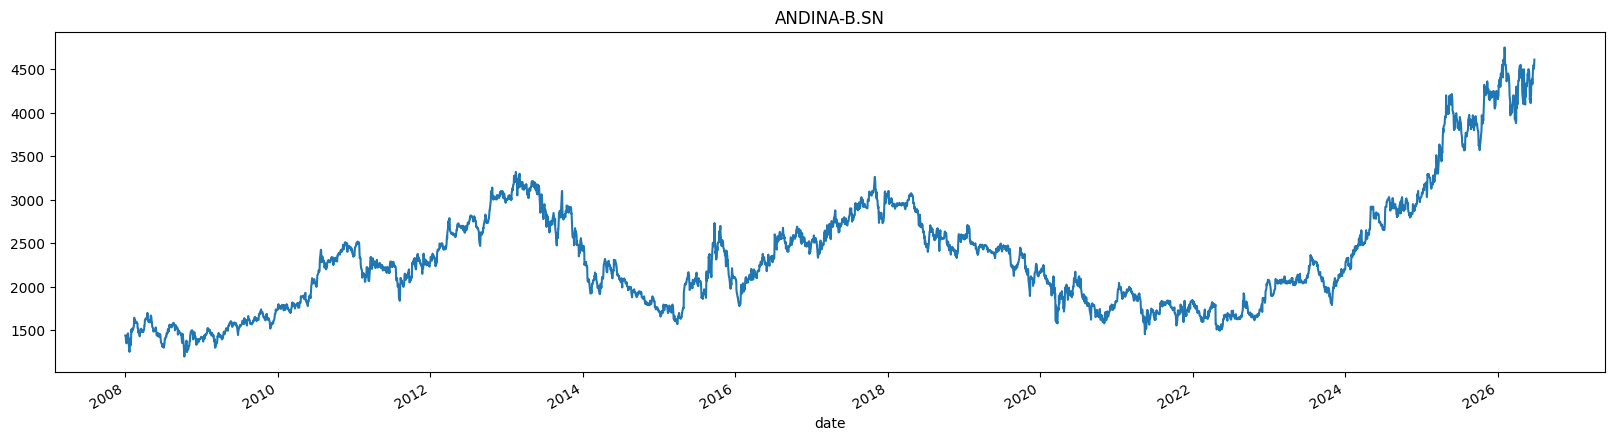

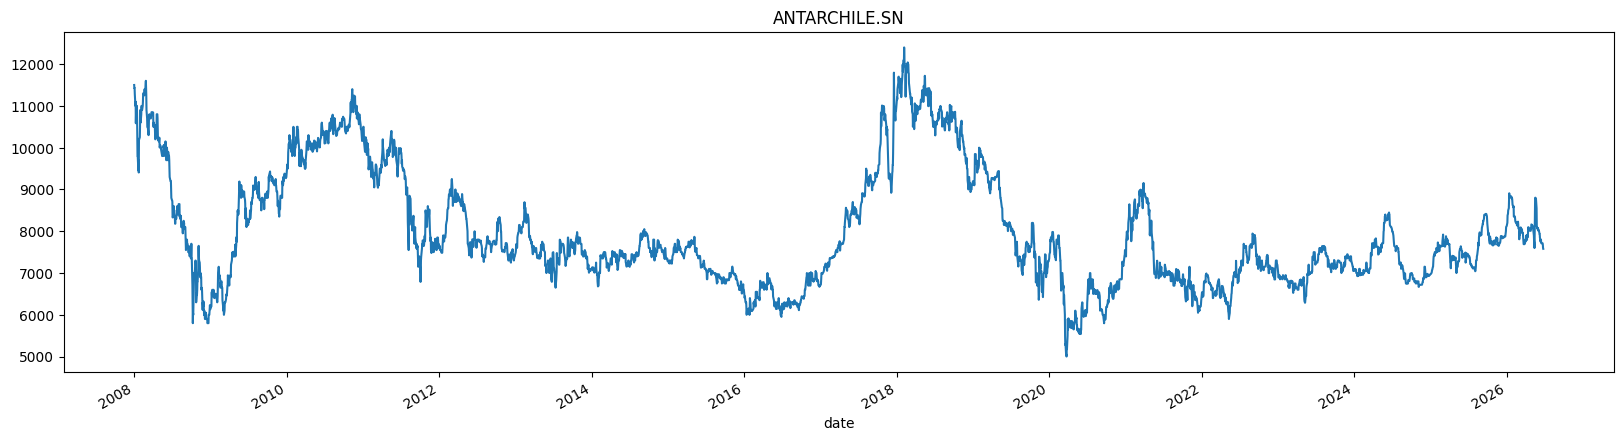

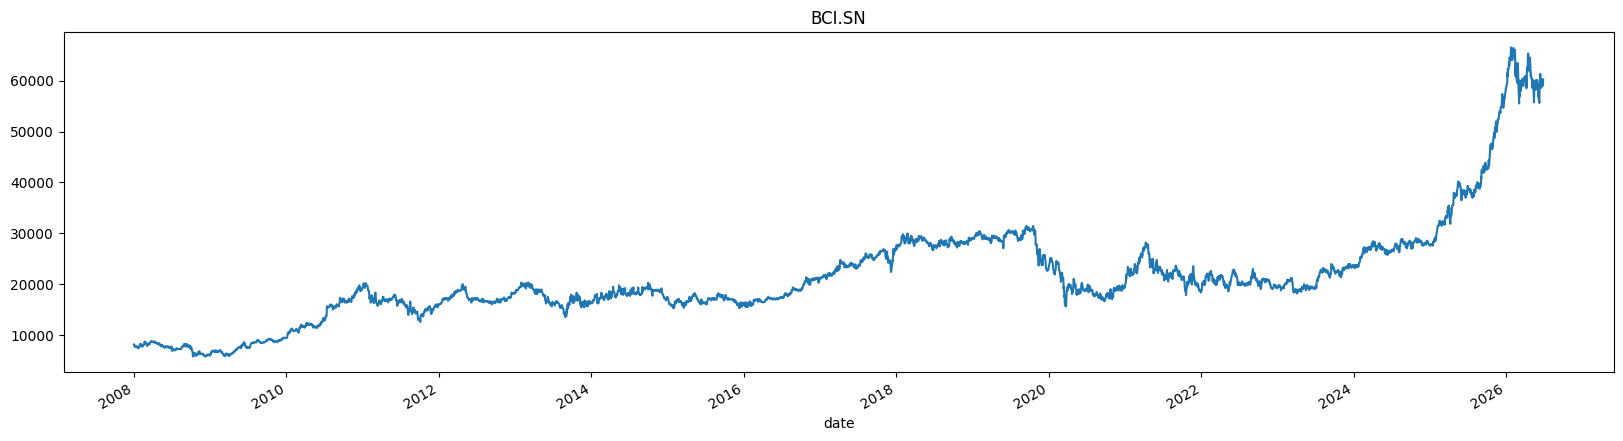

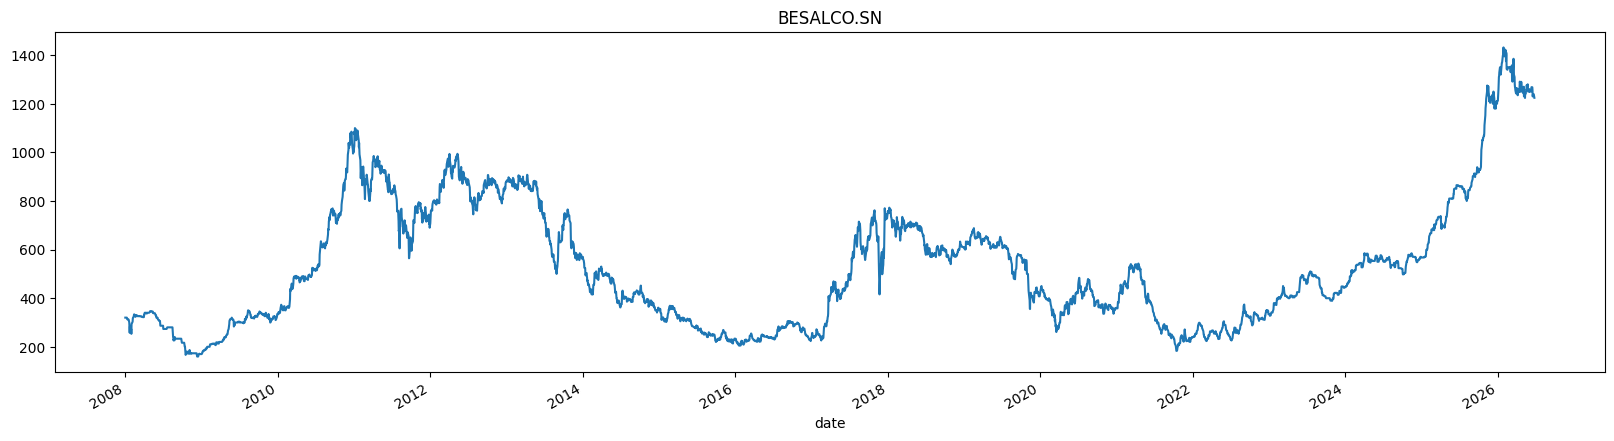

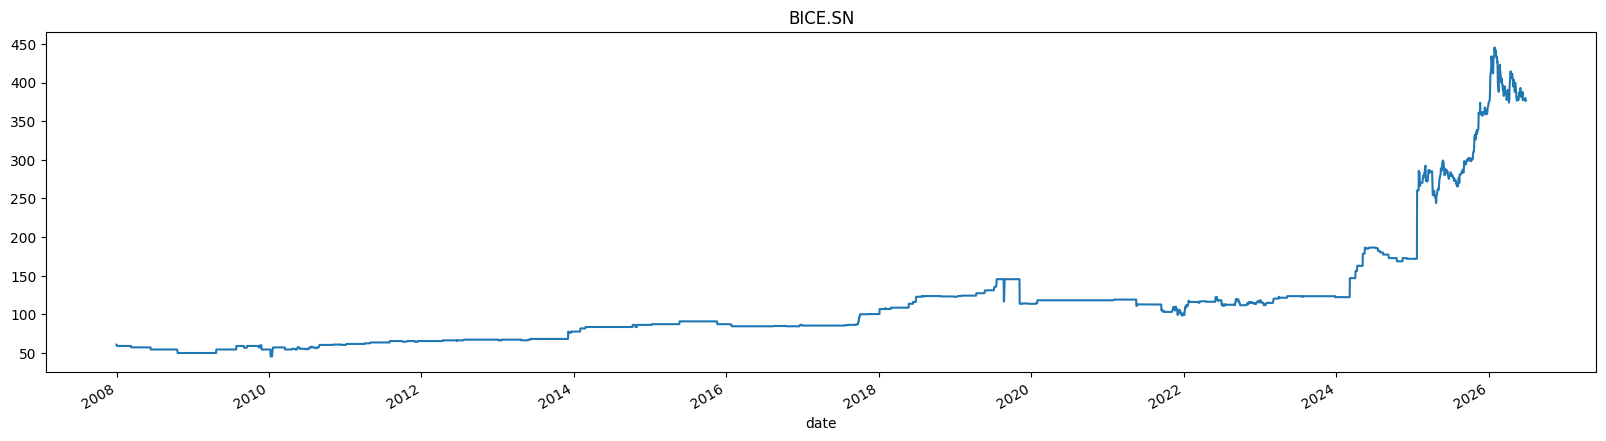

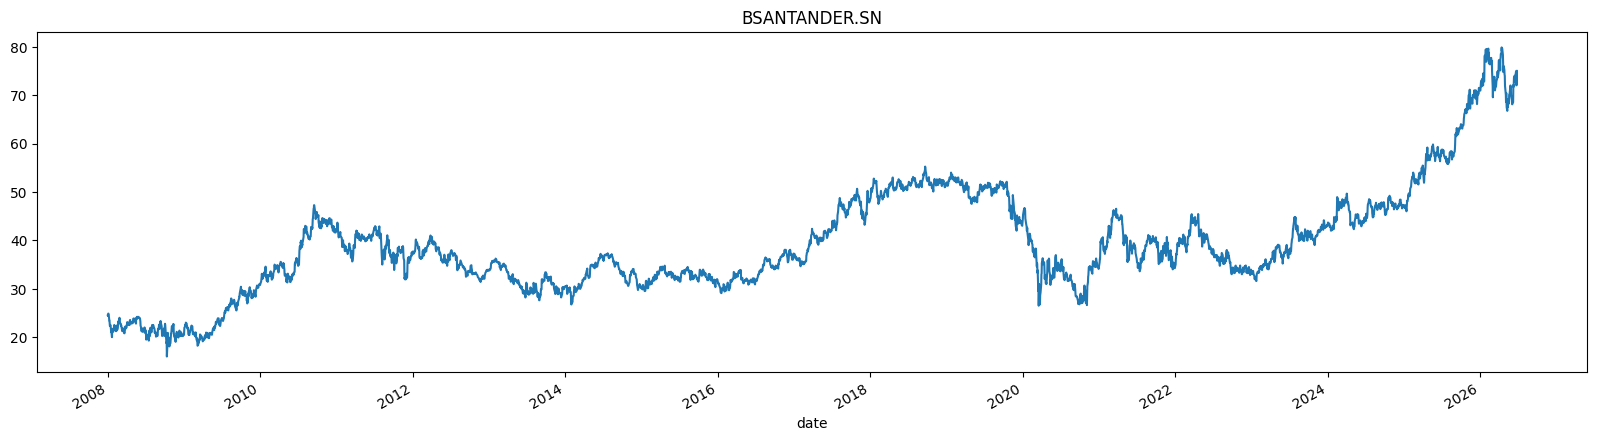

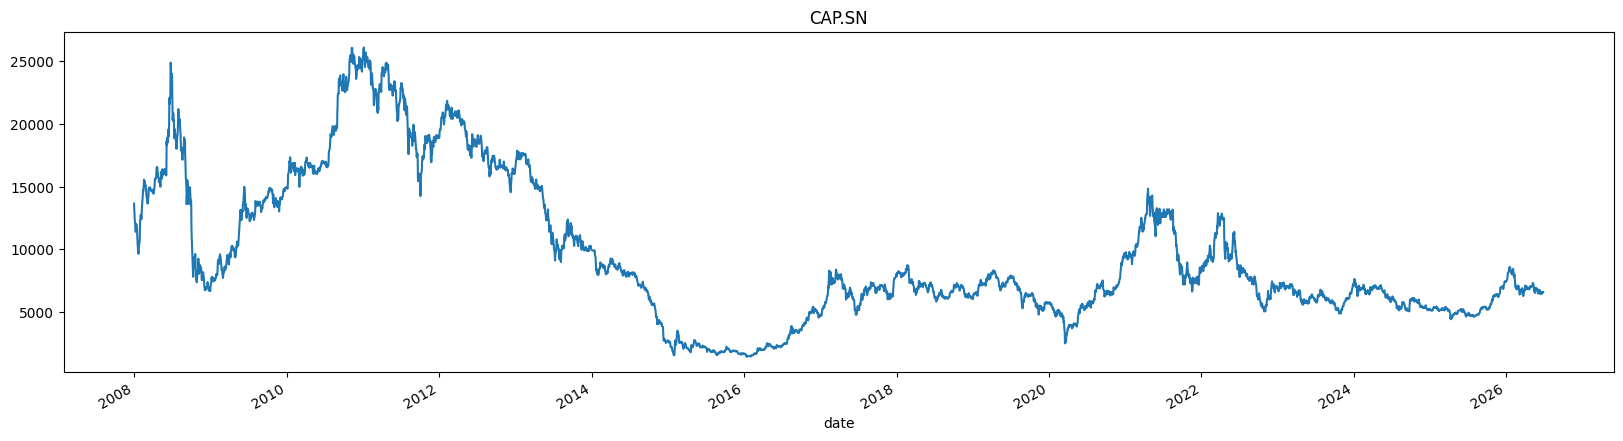

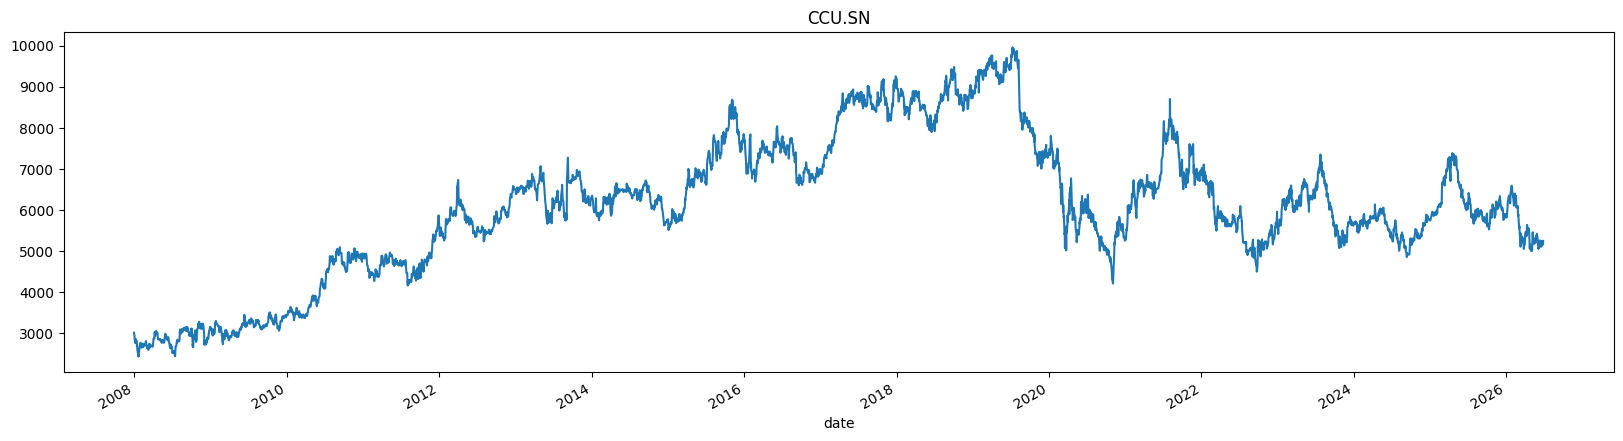

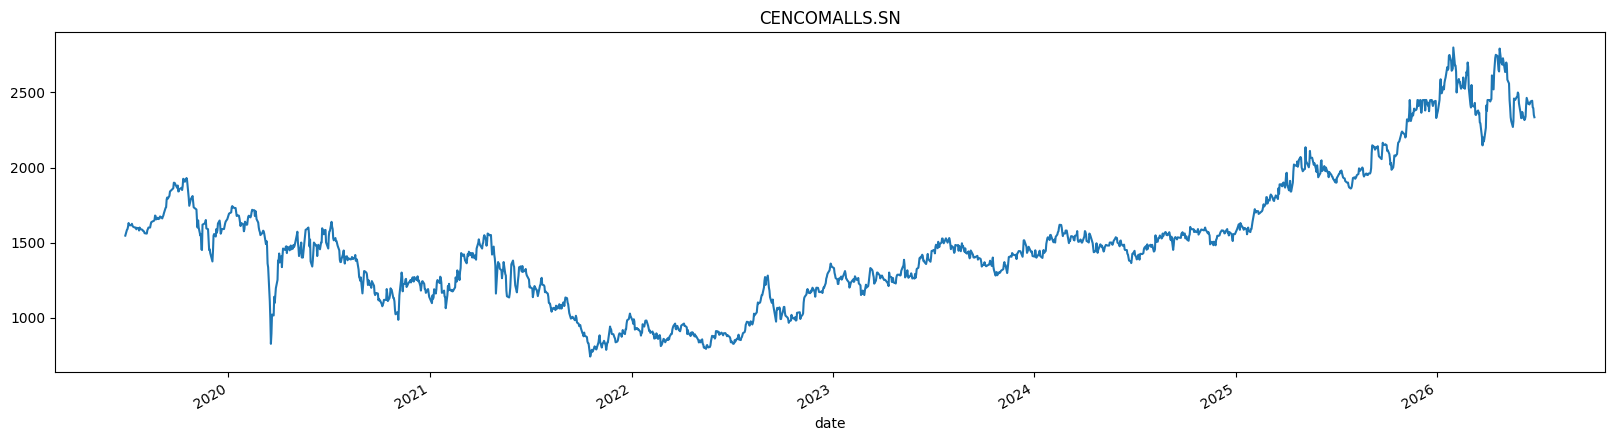

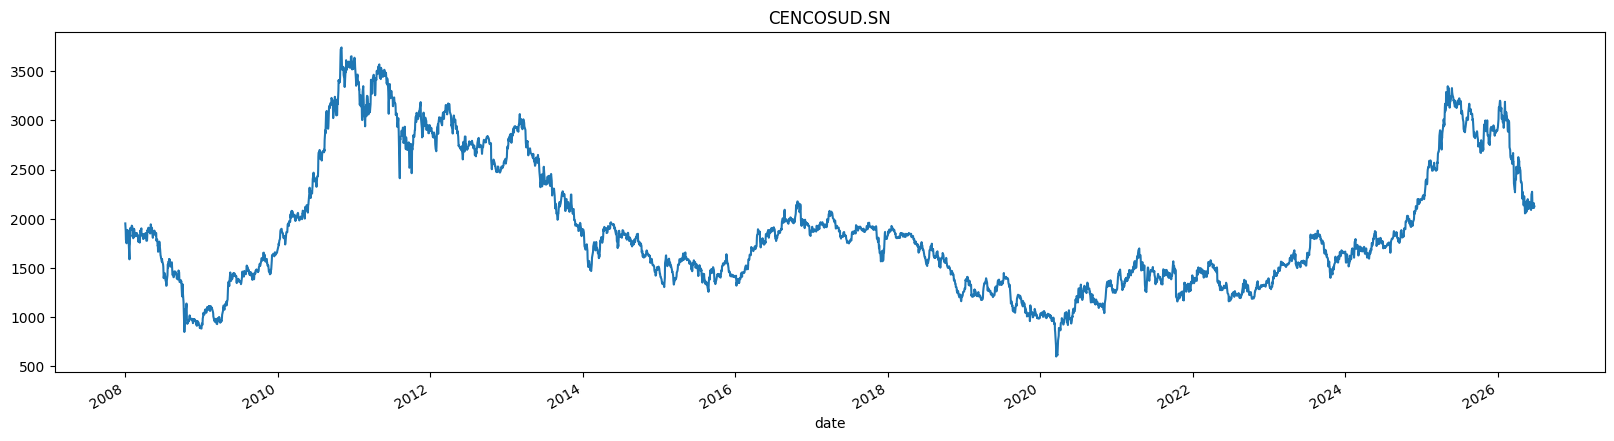

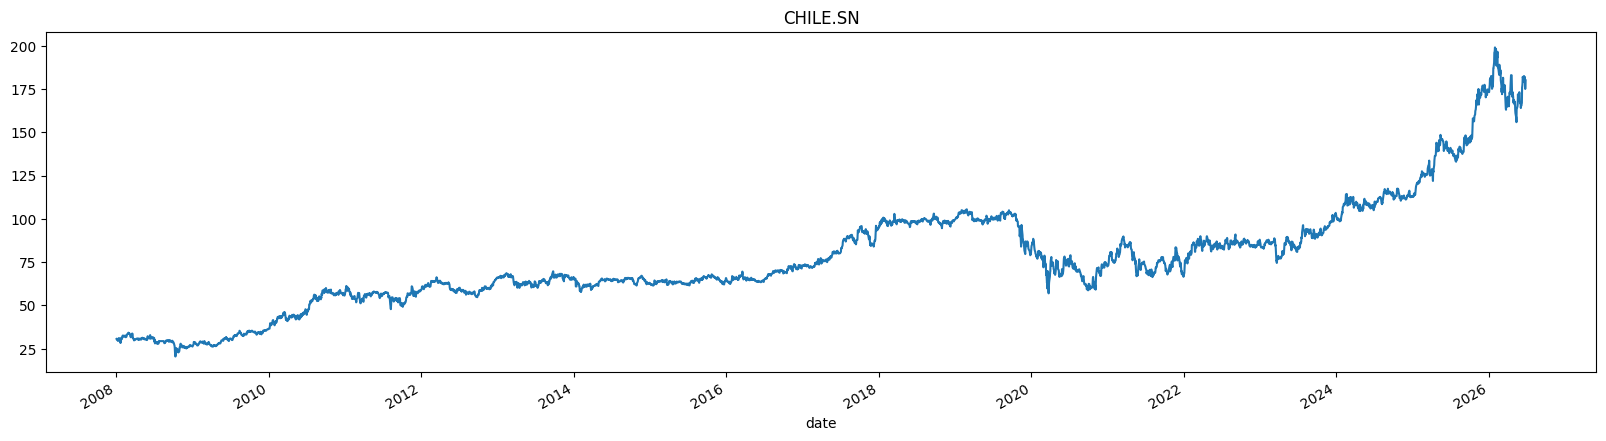

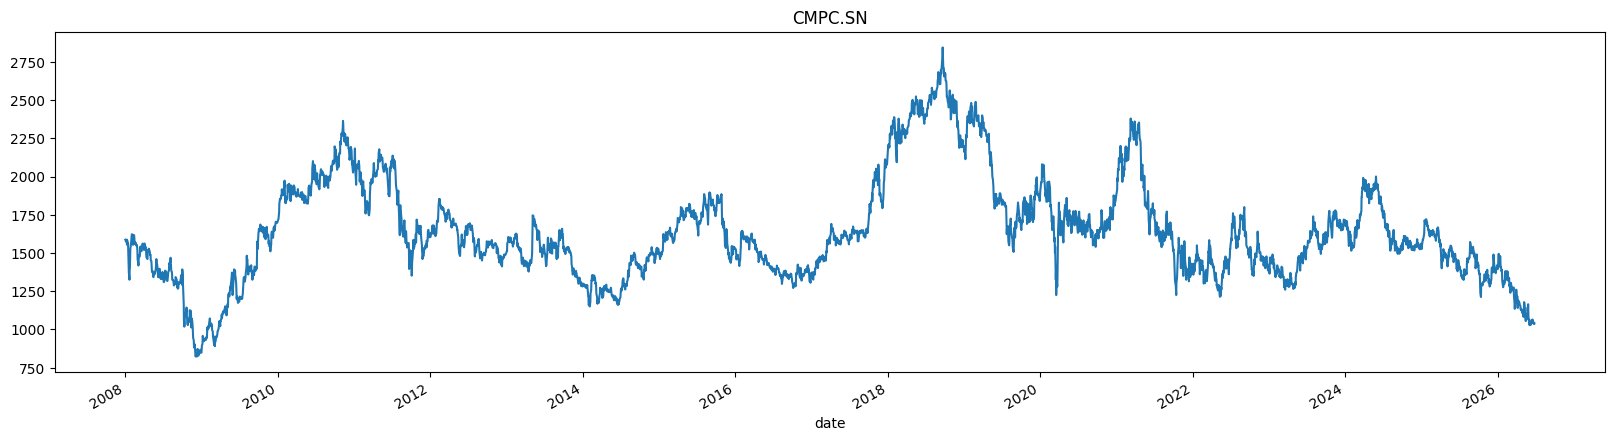

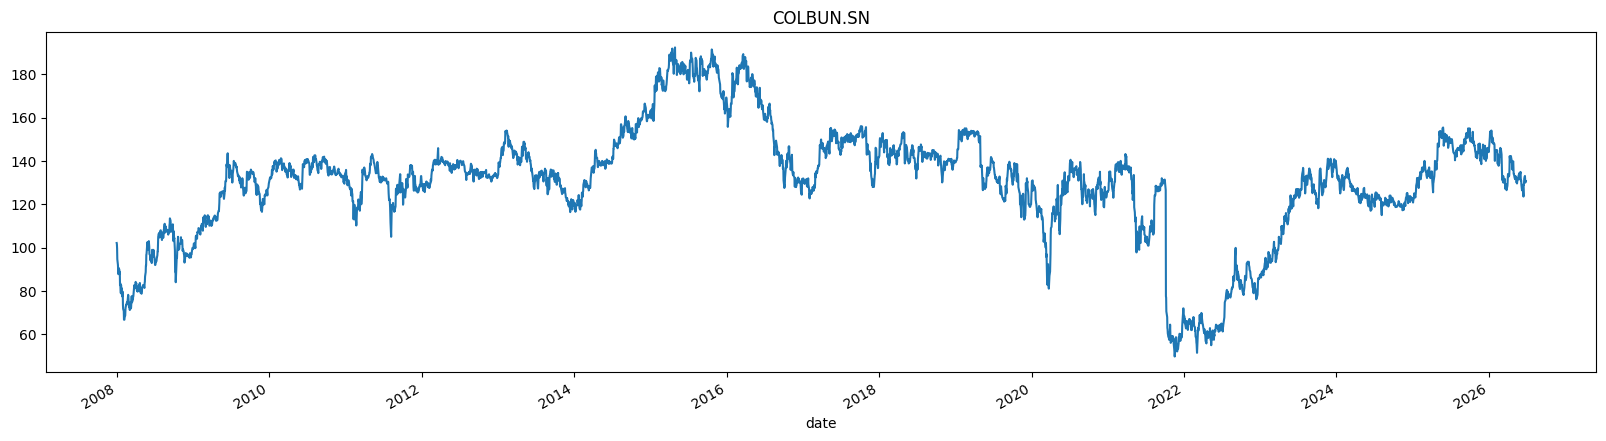

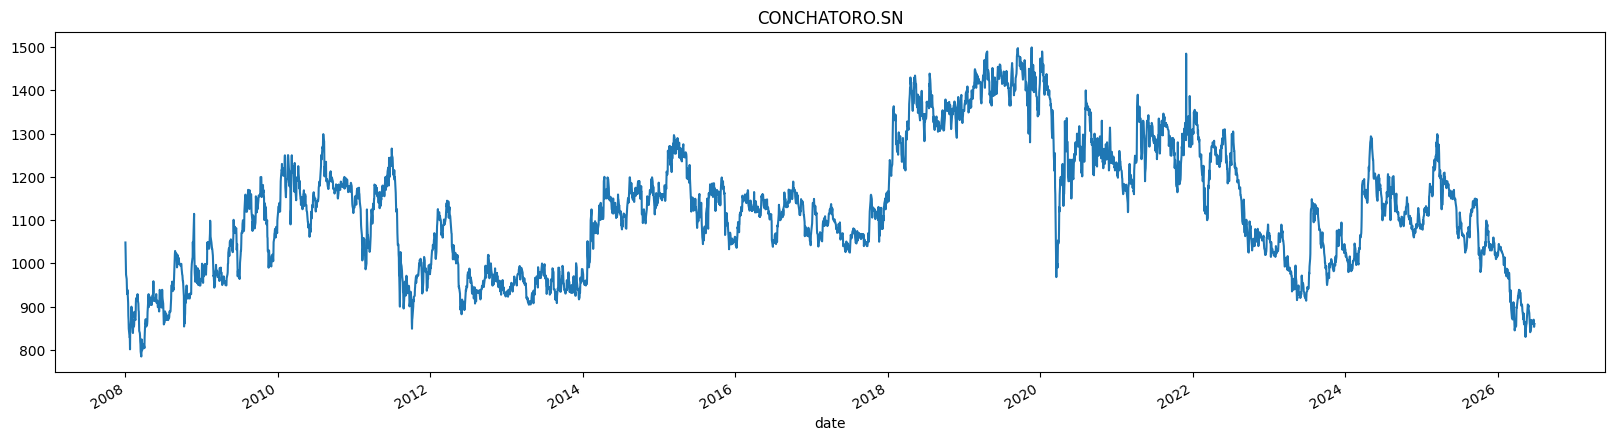

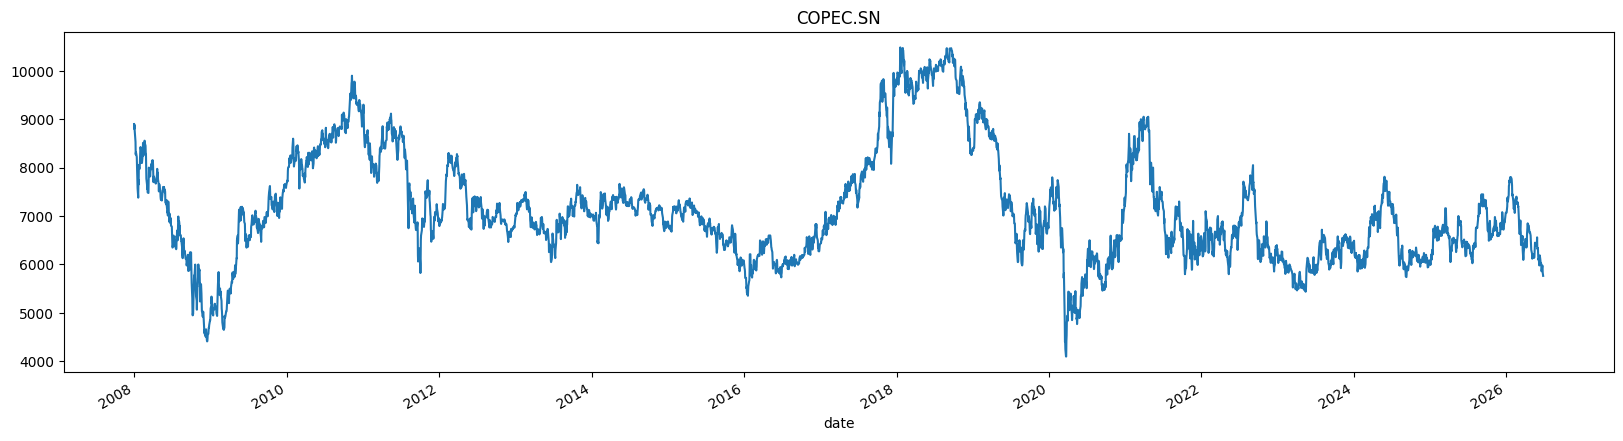

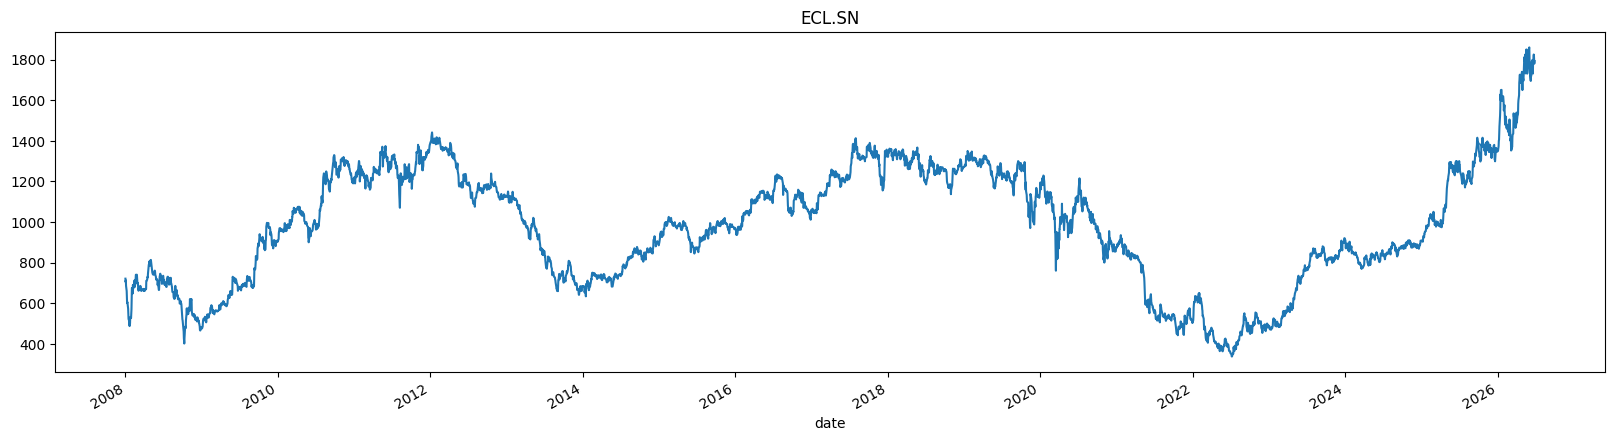

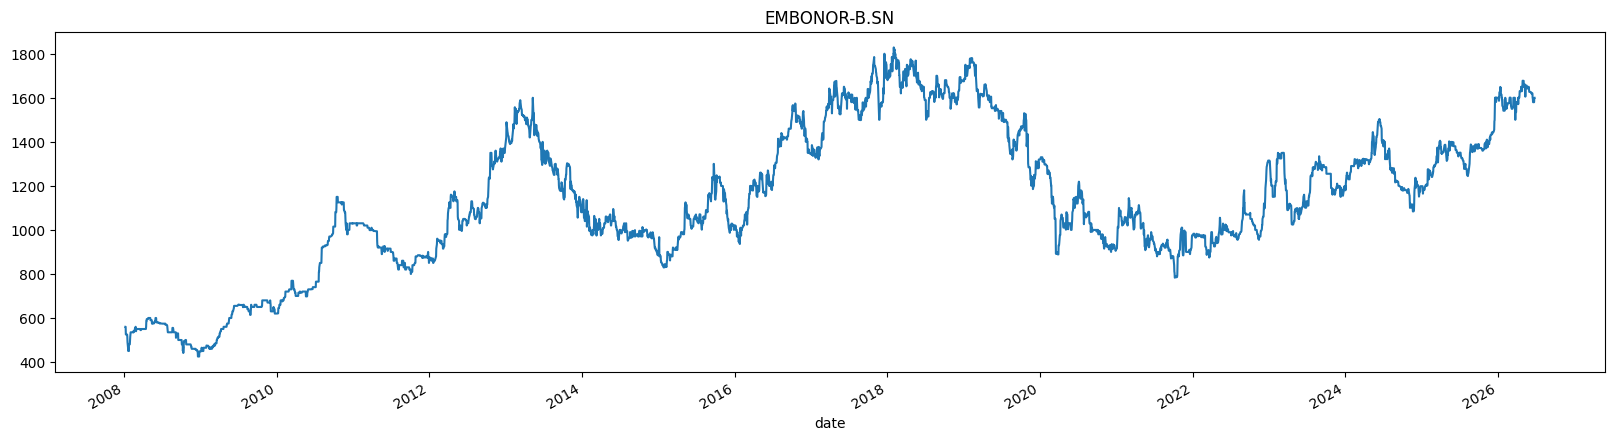

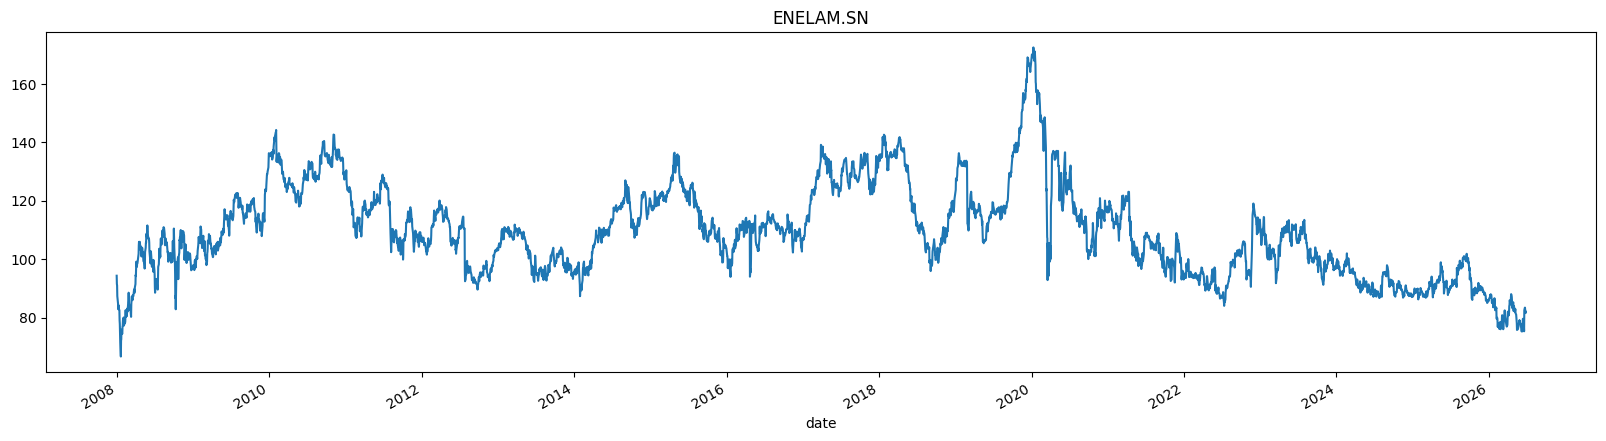

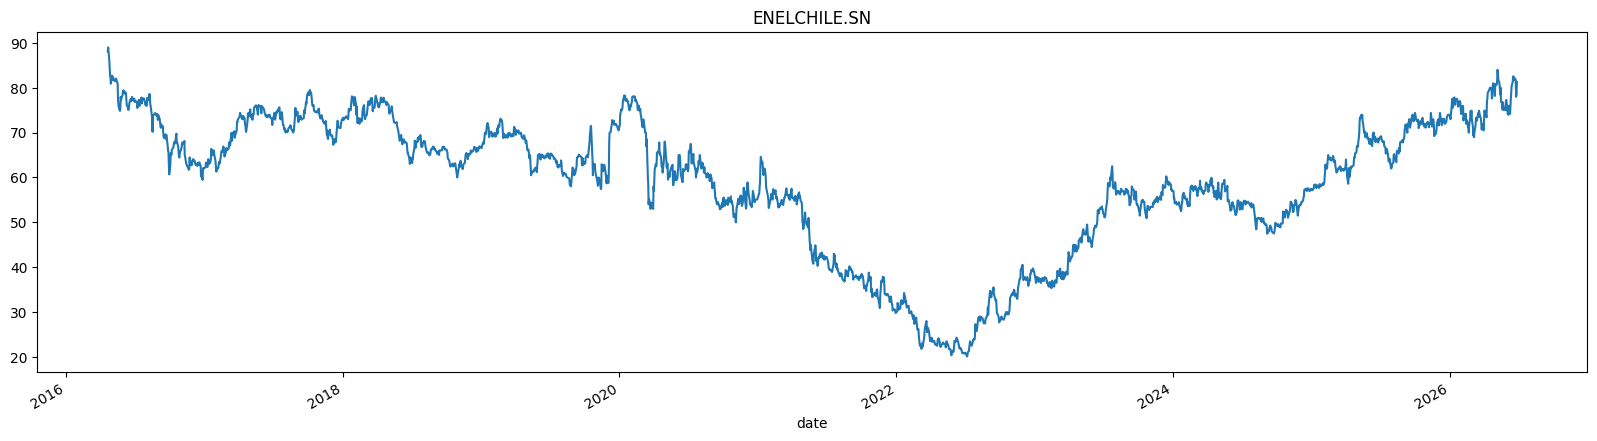

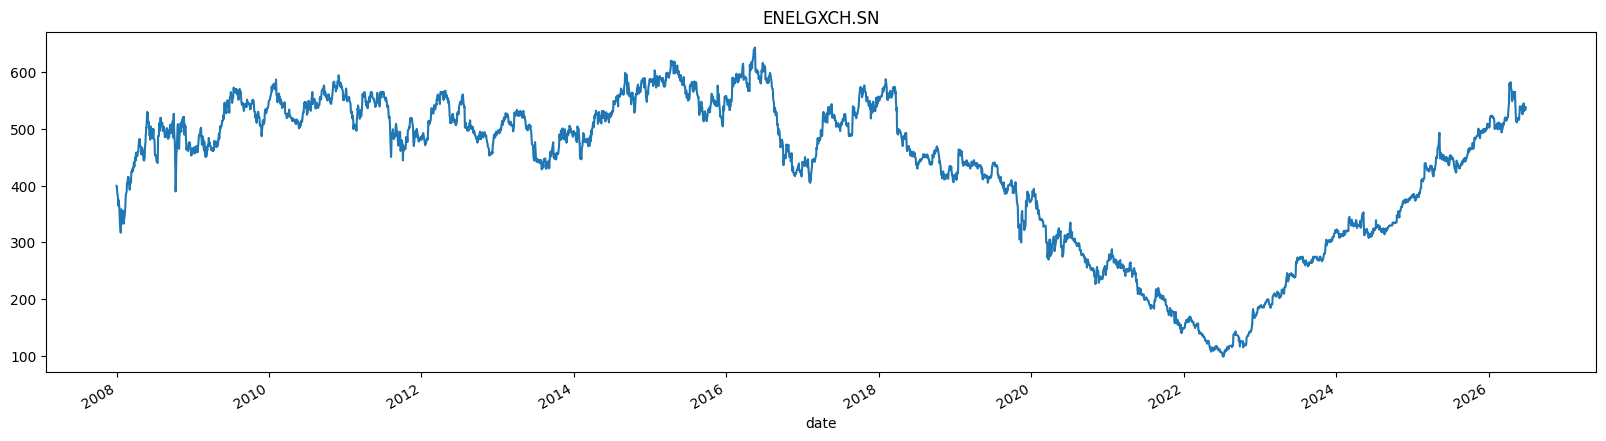

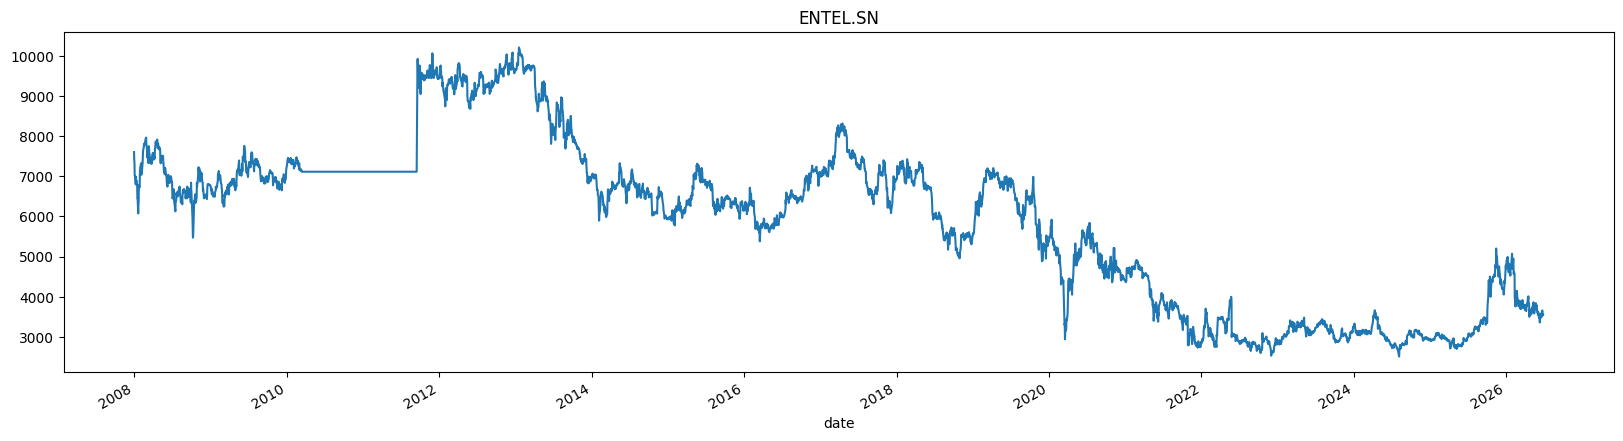

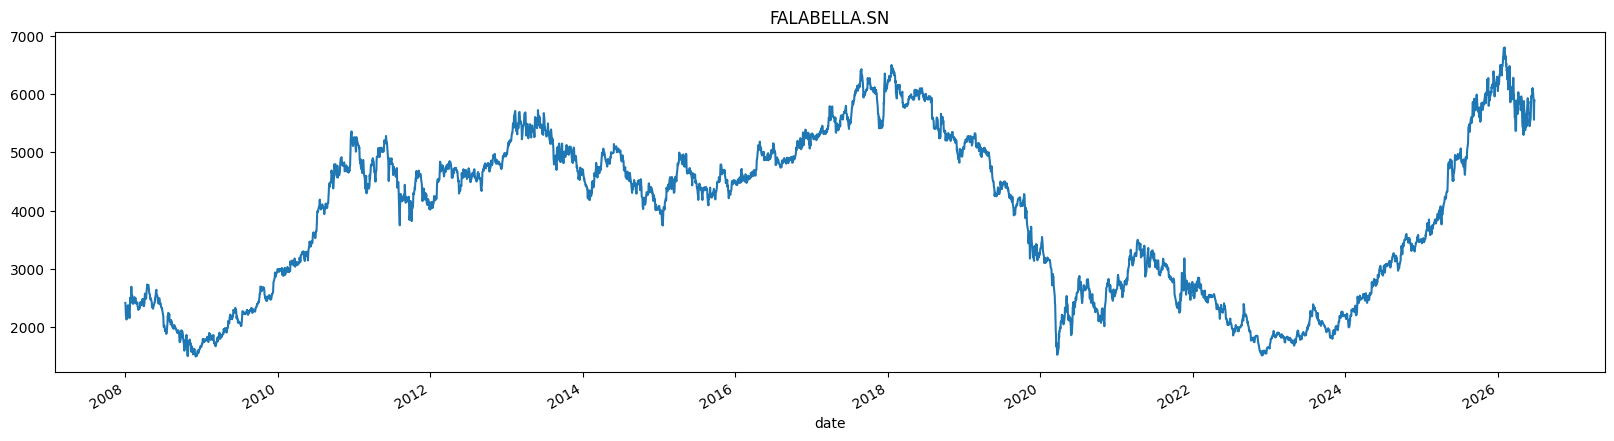

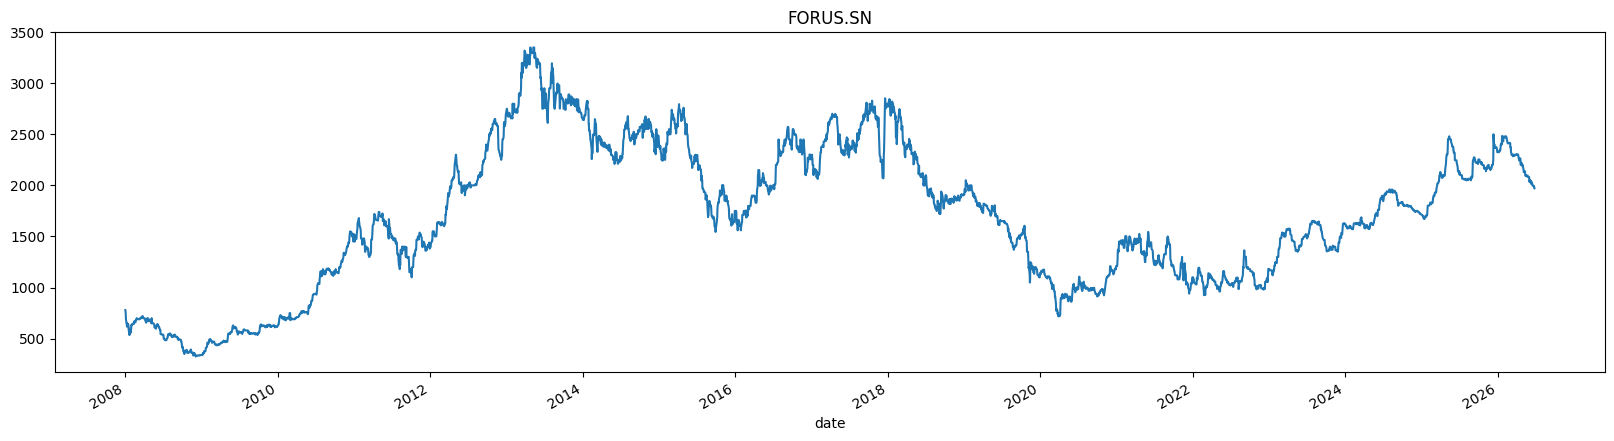

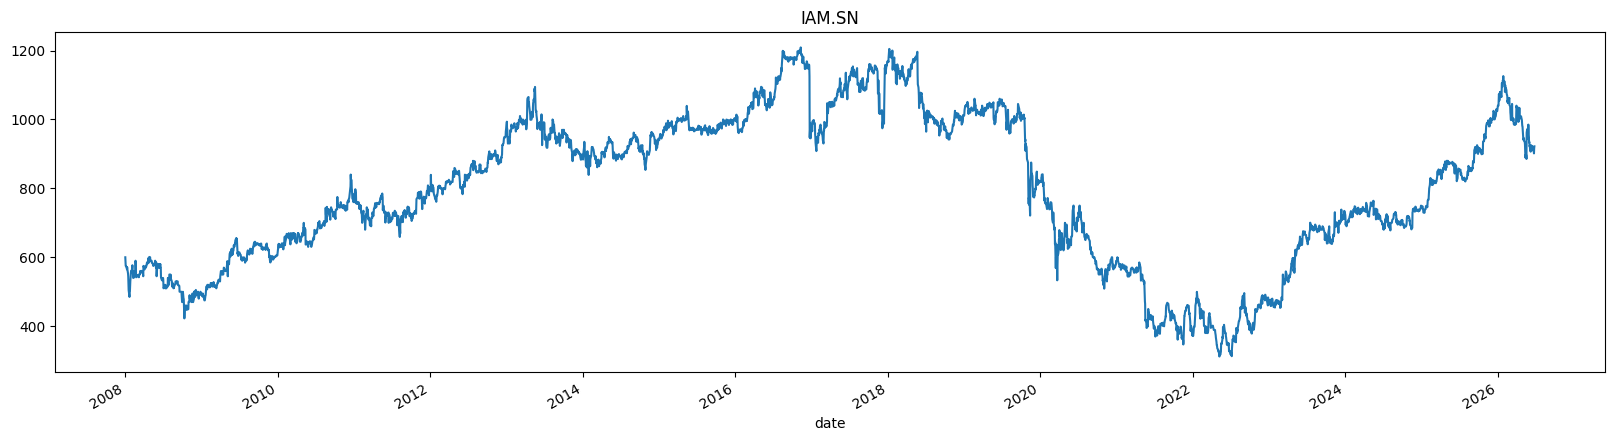

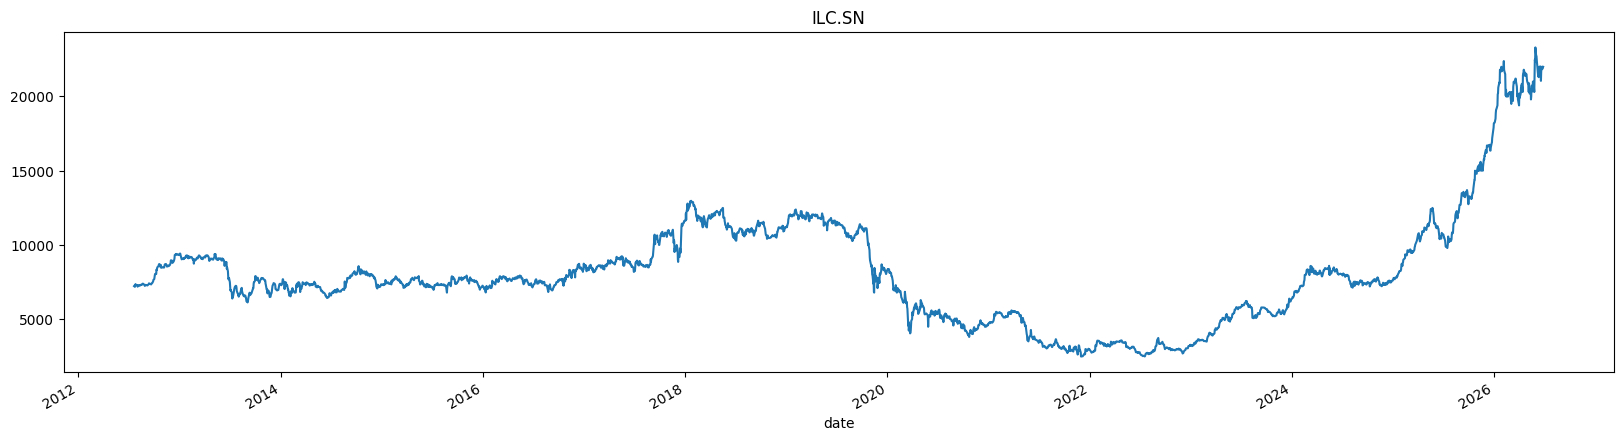

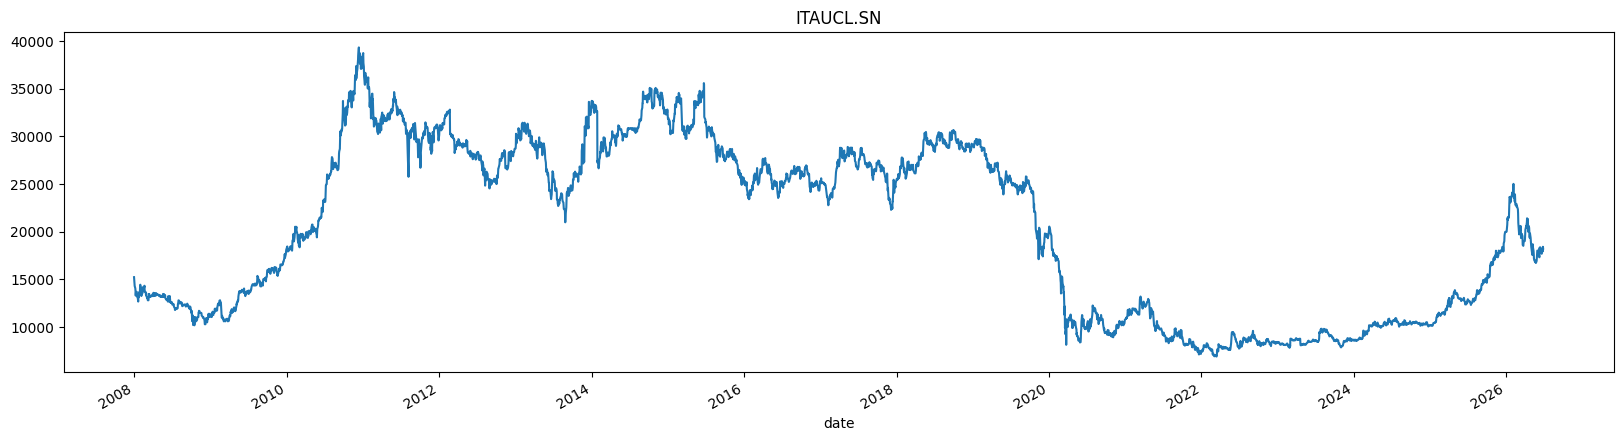

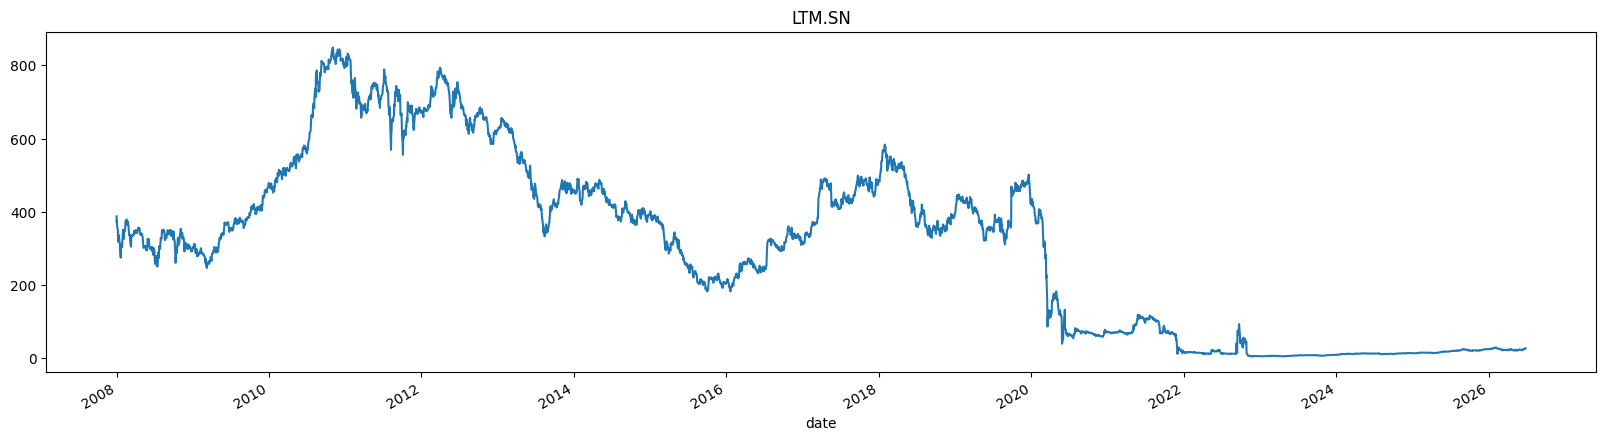

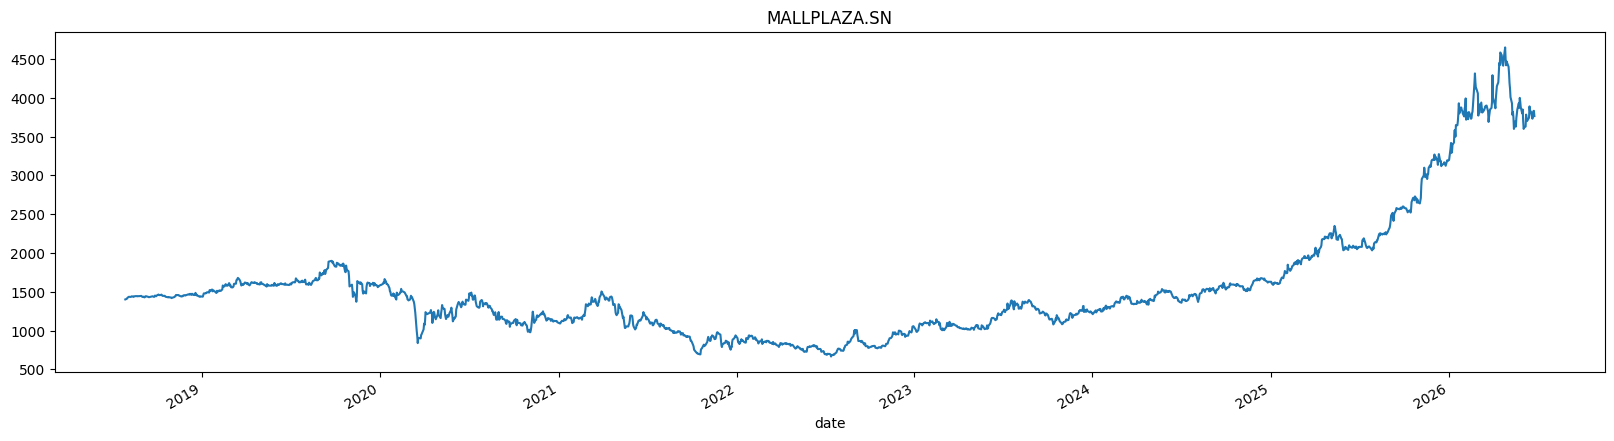

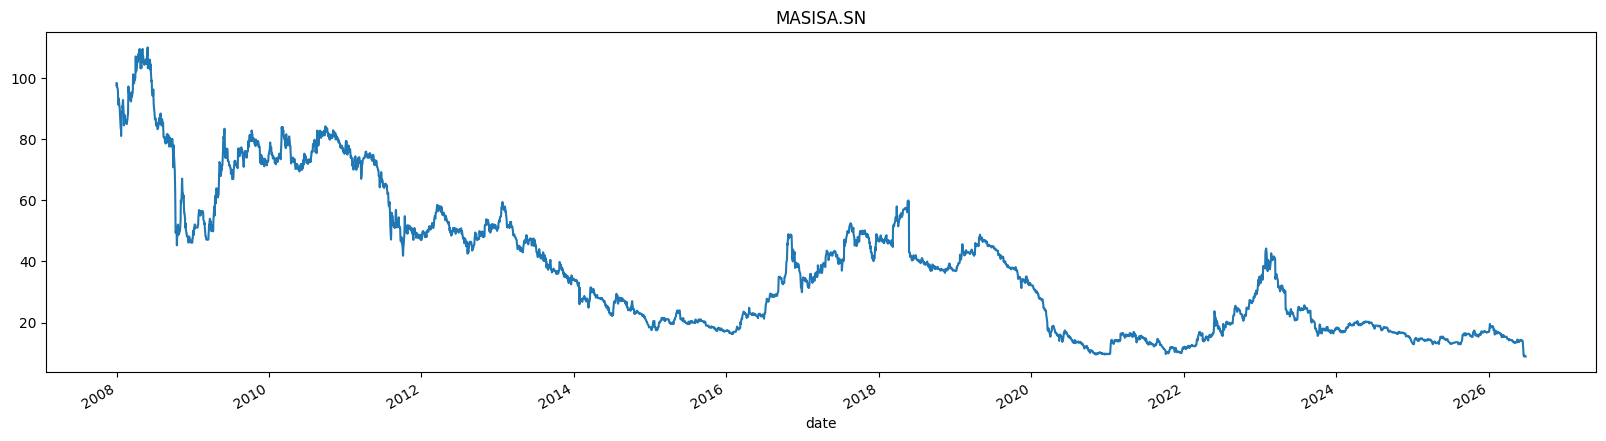

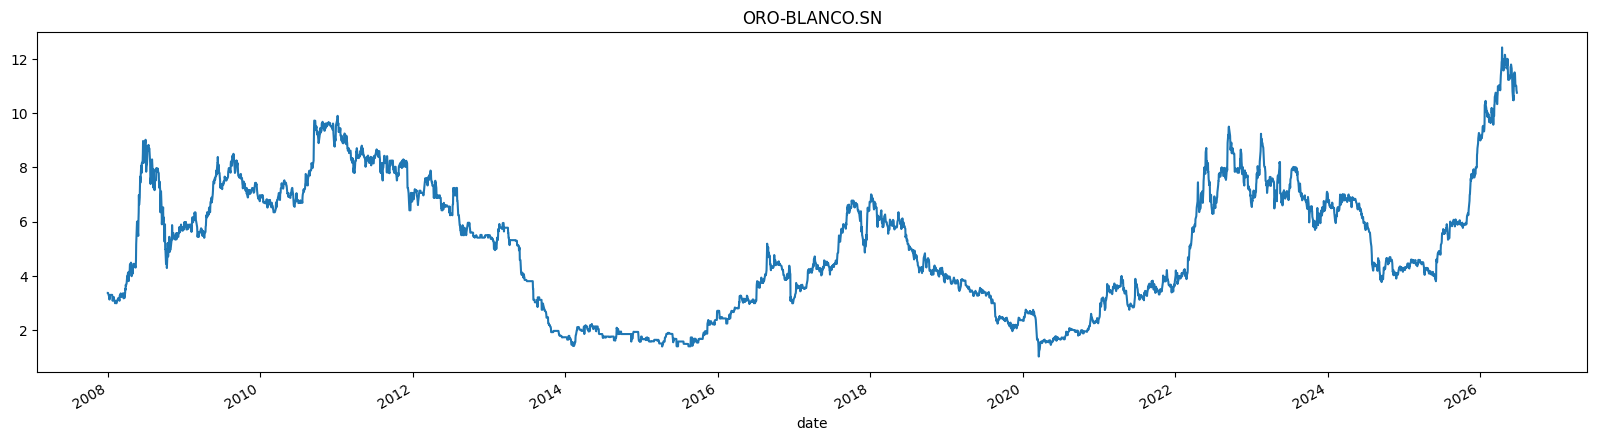

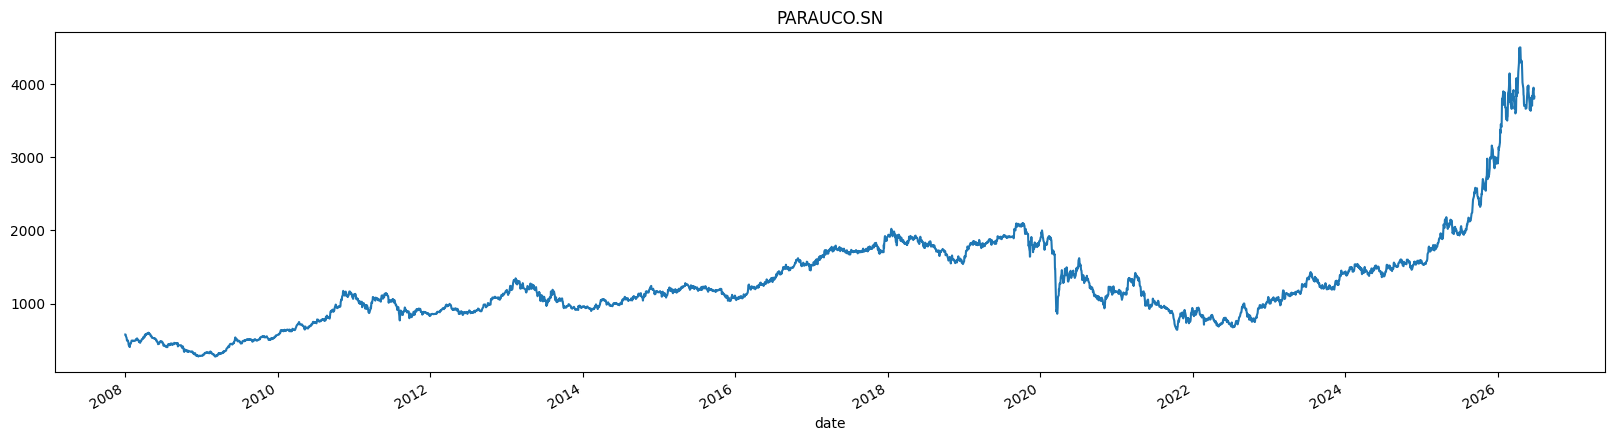

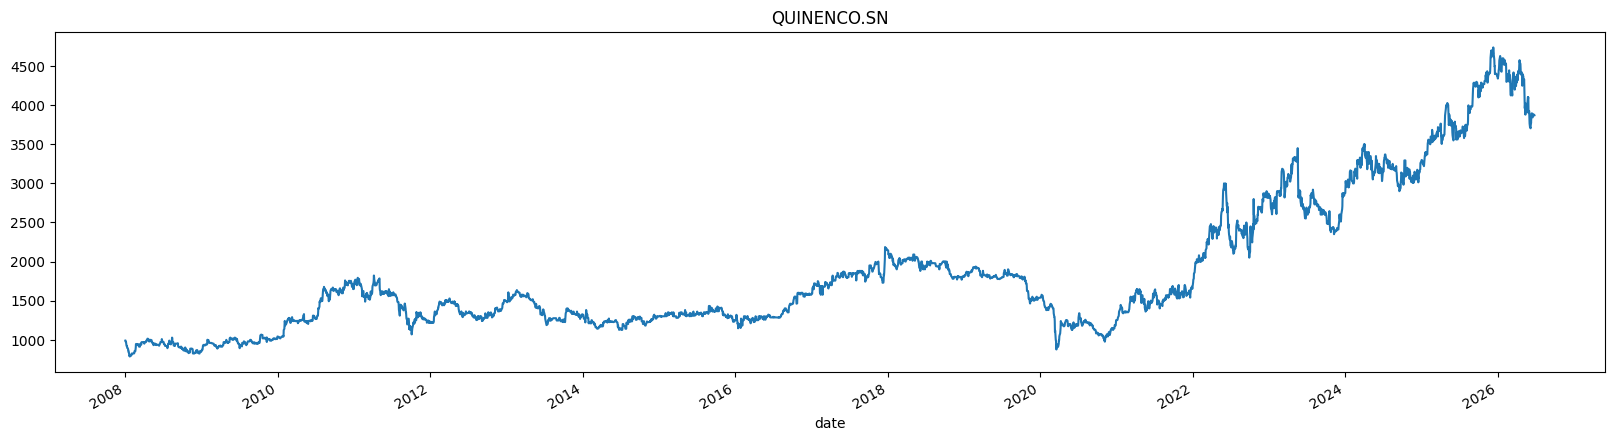

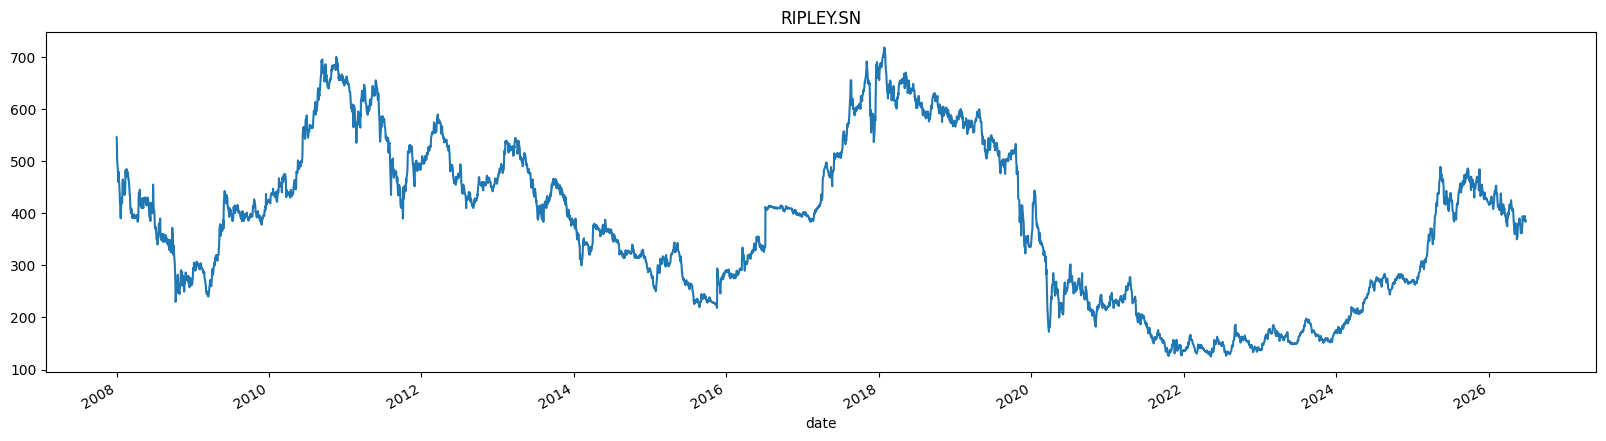

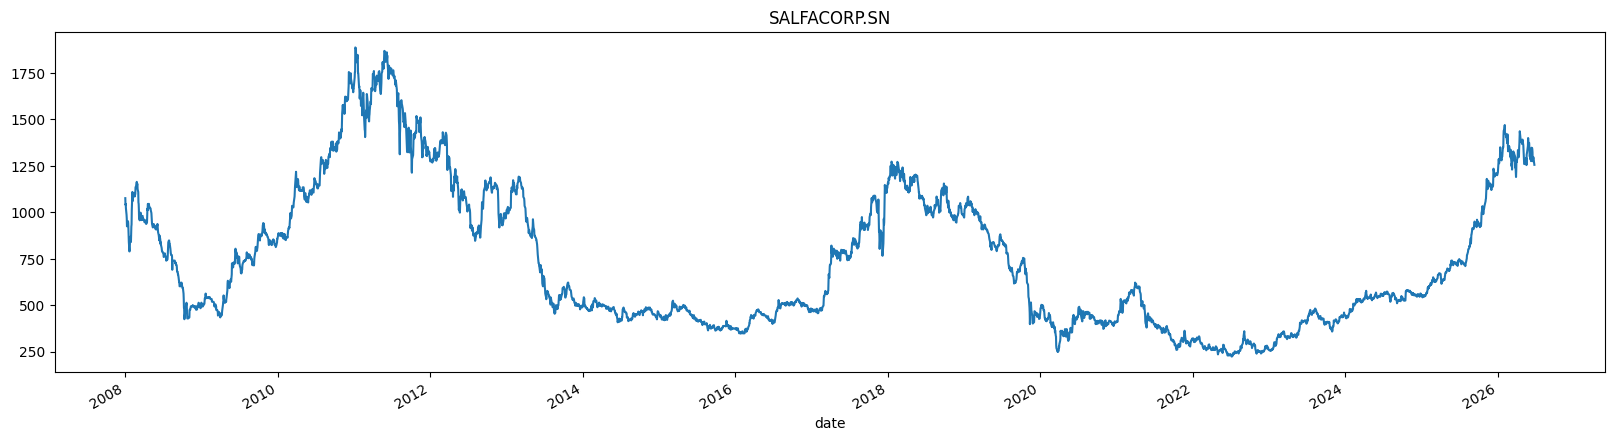

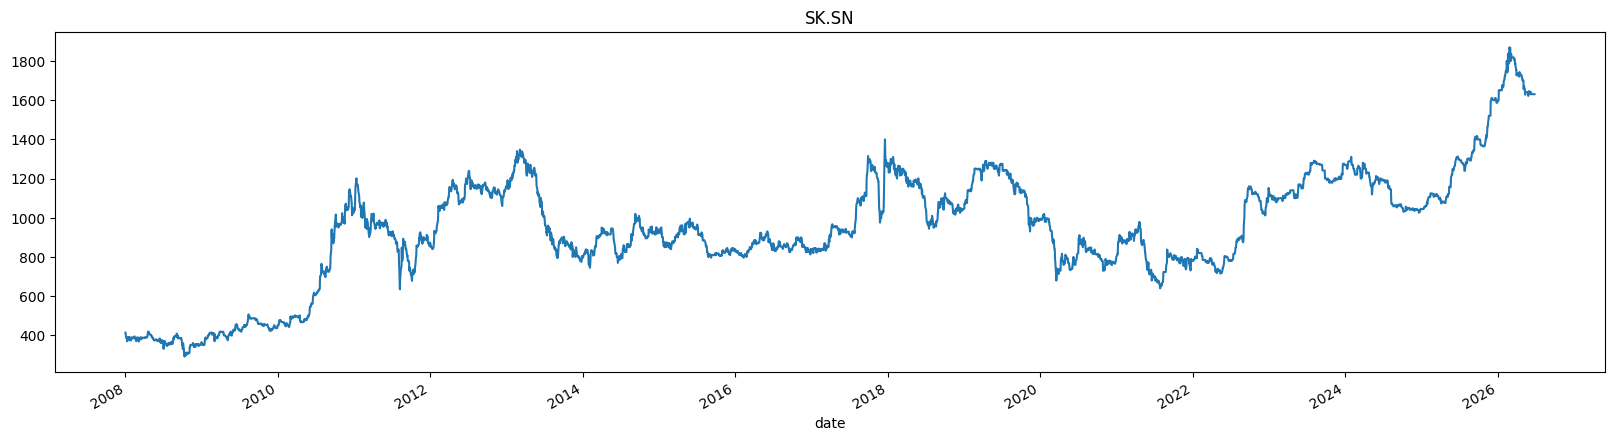

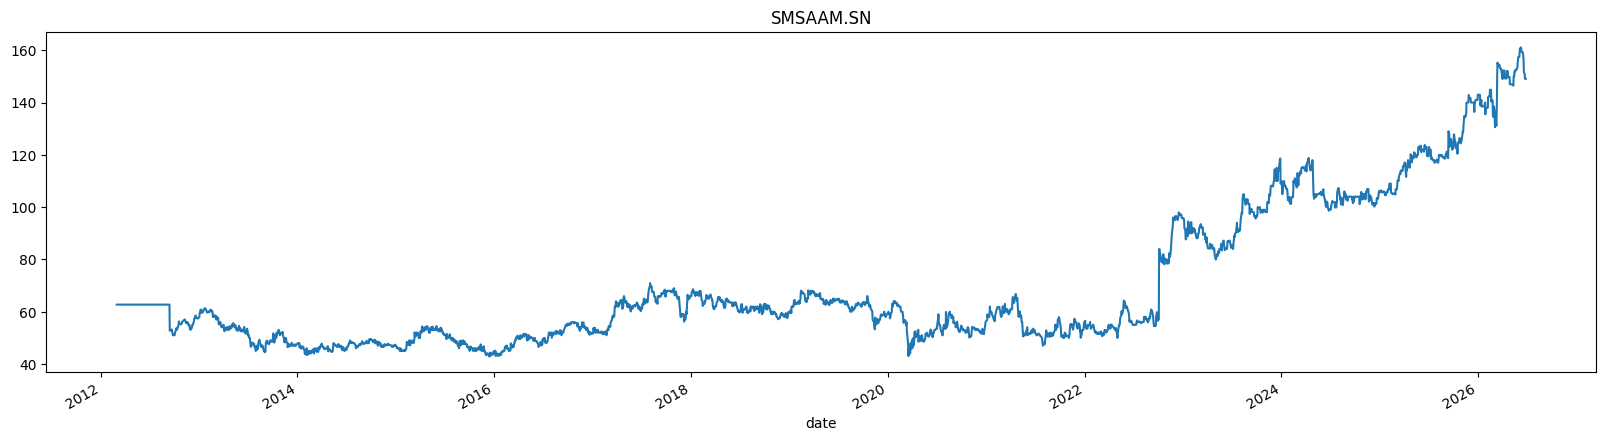

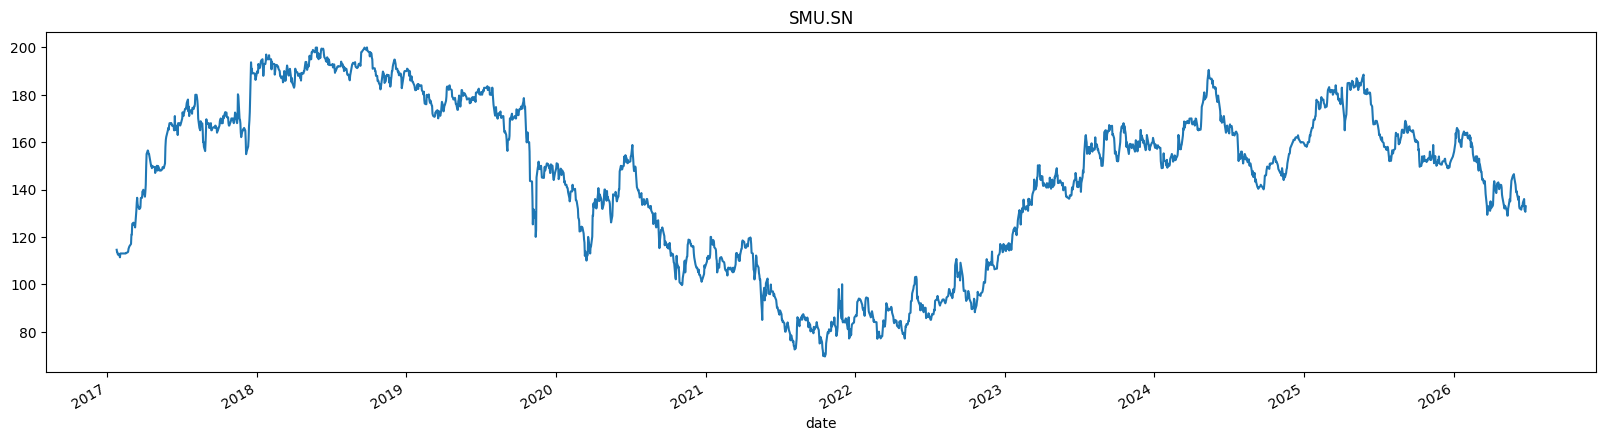

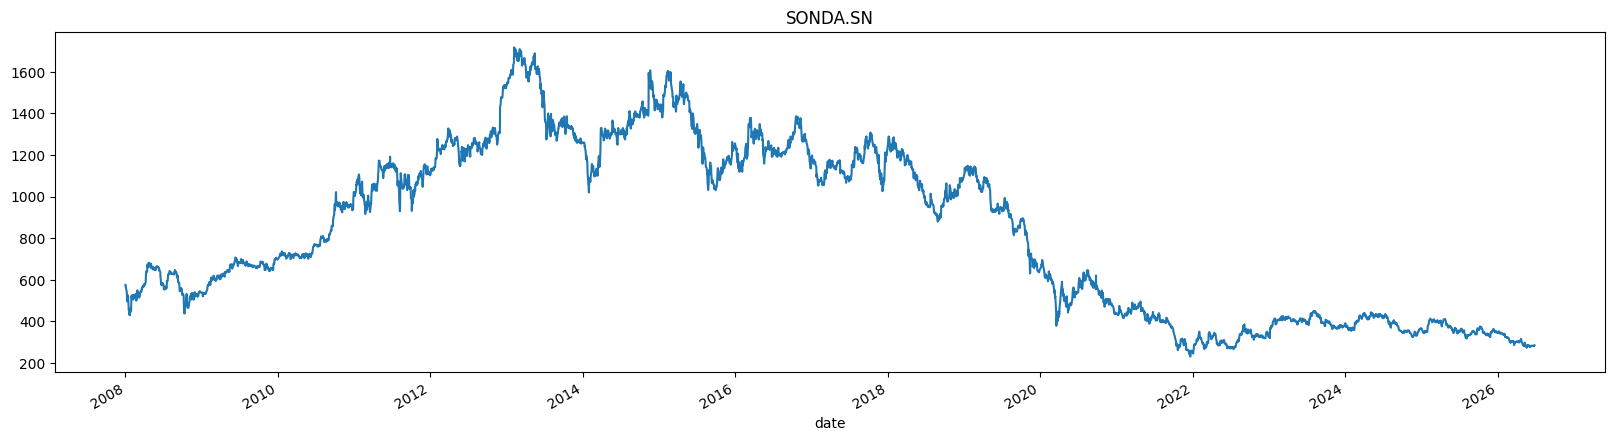

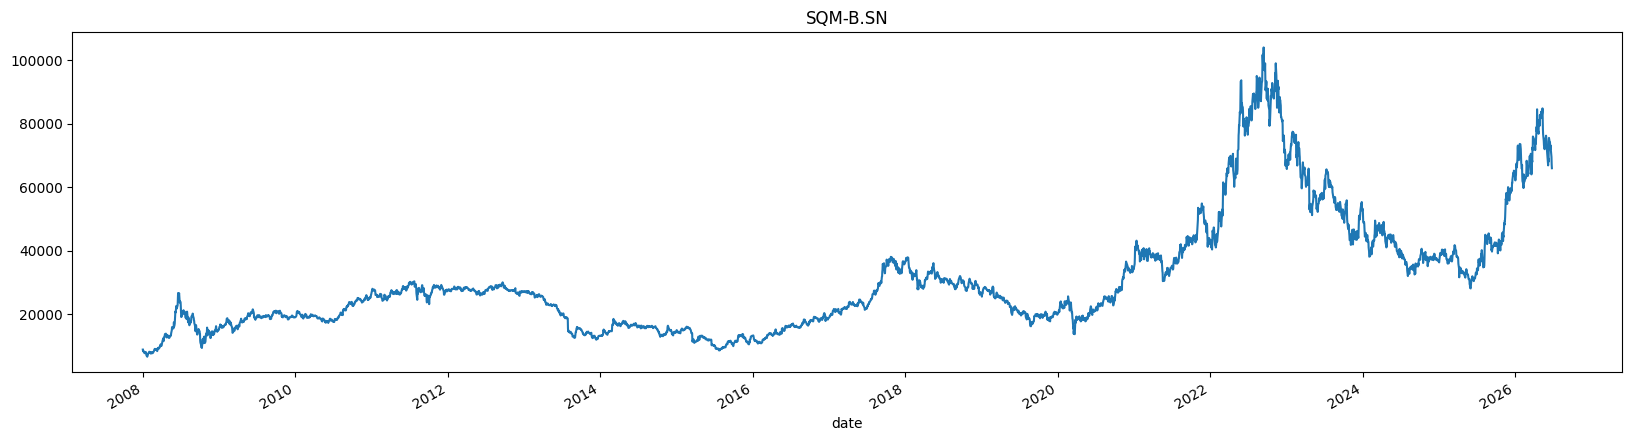

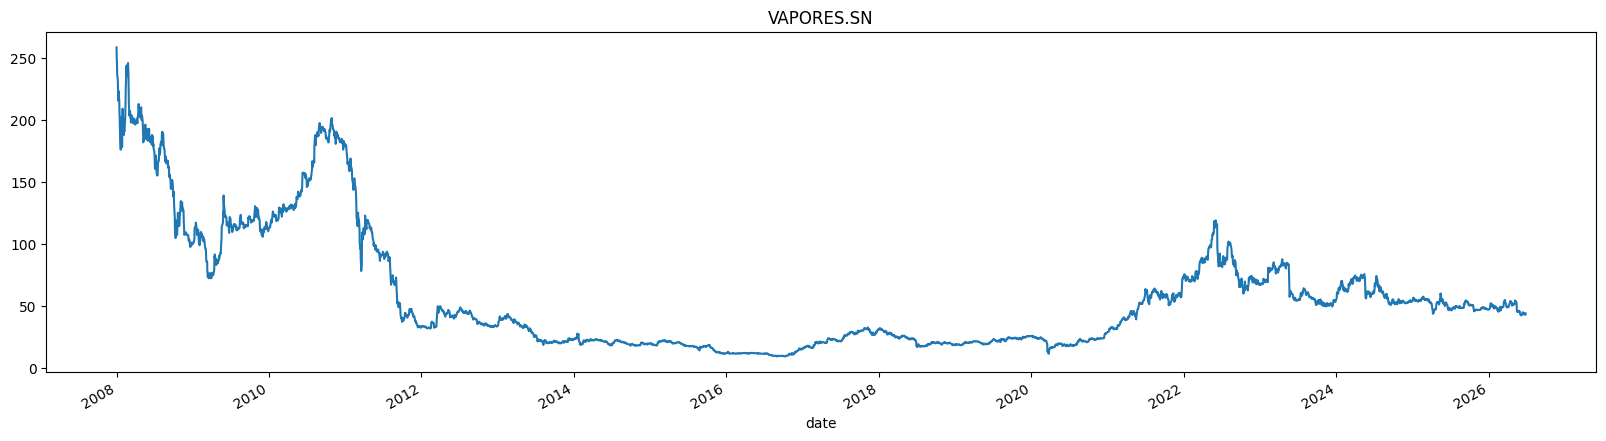

In [75]:
for ticker, df_ticker in dfSource.groupby(level="ticker"):
    df_ticker = df_ticker.droplevel("ticker")

    fig = plt.figure(figsize=(20,5))
    ax = fig.subplots()

    df_ticker["close"].plot(ax=ax)
    plt.title(ticker)
    plt.show()


## Calculamos el portafolio Buy & Hold

In [79]:
import pandas as pd

portfolio = []

for ticker, df_ticker in dfSource.groupby(level="ticker"):

    df_ticker = (
        df_ticker
        .droplevel("ticker")
        .sort_index()
        .copy()
    )

    price = df_ticker["adj close"]

    # Acciones compradas inicialmente
    shares = int(INITIAL_PER_TICKER / price.iloc[0])

    shares_history = []

    last_month = price.index[0].to_period("M")

    for date, p in price.items():

        current_month = date.to_period("M")

        # Primer día disponible de un nuevo mes
        if current_month != last_month:
            shares += MONTHLY_PER_TICKER / p
            last_month = current_month

        shares_history.append(shares)

    df_ticker["shares"] = shares_history
    df_ticker["equity"] = df_ticker["shares"] * price

    portfolio.append(df_ticker["equity"])

# ==========================================
# Equity total
# ==========================================

equity = (
    pd.concat(portfolio, axis=1)
      .sum(axis=1)
      .to_frame("Capital final")
      .reset_index()
)

equity.columns = ["Periodo", "Capital final"]
equity.head()

,Periodo,Capital final
0,2008-01-01,289072.164501
1,2008-01-02,314396.488951
2,2008-01-03,312020.485241
3,2008-01-04,304083.876582
4,2008-01-07,307521.827037


## Graficamos la curva de patrimonio

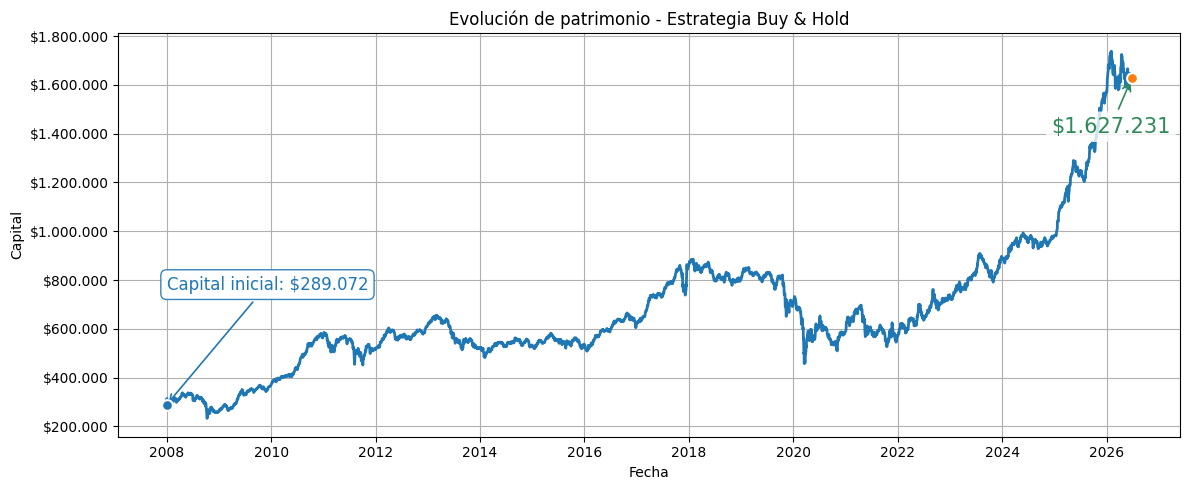

In [80]:


def formato_clp(x, pos):
    return f"${x:,.0f}".replace(",", ".")

fig, ax = plt.subplots(figsize=(12,5))

ax.plot(equity['Periodo'], equity['Capital final'], linewidth=2)

ax.set_title('Evolución de patrimonio - Estrategia Buy & Hold')
ax.set_xlabel('Fecha')
ax.set_ylabel('Capital')

# Formato de moneda chilena
ax.yaxis.set_major_formatter(FuncFormatter(formato_clp))

ax.grid(True)

# Primer punto real
x0 = equity.iloc[0]["Periodo"]
y0 = equity.iloc[0]["Capital final"]

ax.scatter(
    x0,
    y0,
    s=60,
    color='tab:blue',
    edgecolor='white',
    linewidth=1.5,
    zorder=5
)

monto_inicial = equity.iloc[0]["Capital final"]

label_inicio = (
    f"Capital inicial: ${monto_inicial:,.0f}"
).replace(",", ".")
# label_inicio = (
#     f"Capital inicial: ${monto_inicial:,.0f}\n"
#     f"Aporte mensual: ${MONTHLY_CONTRIBUTION:,.0f}"
# ).replace(",", ".")

ax.annotate(
    label_inicio,
    xy=(x0, y0),
    xytext=(0, 80),
    textcoords='offset points',
    color='tab:blue',
    fontsize=12,
    ha='left',
    va='bottom',
    multialignment='left',
    arrowprops=dict(
        arrowstyle='->',
        color='tab:blue',
        lw=1.2
    ),
    bbox=dict(
        boxstyle='round,pad=0.35',
        fc='white',
        ec='tab:blue',
        alpha=0.9
    )
)

#punto final
x_last = equity.iloc[-1]["Periodo"]
y_last = equity.iloc[-1]["Capital final"]


ax.scatter(
    x_last,
    y_last,
    s=60,
    color='tab:orange',
    edgecolor='white',
    linewidth=1.5,
    zorder=5
)

label_final = f"${y_last:,.0f}".replace(",", ".")

ax.annotate(
    label_final,
    xy=(x_last, y_last),
    xytext=(-15, -35),
    textcoords='offset points',
    color='seagreen',
    fontsize=15,
    ha='center',
    va='center',
    arrowprops=dict(
        arrowstyle='->',
        color='seagreen',
        lw=1.2
    ),
    bbox=dict(
        boxstyle='round,pad=0.25',
        fc='white',
        ec='none',
        alpha=0.8
    )
)

plt.tight_layout()
plt.show()